# 🌍 **Proyecto: Inteligencia Artificial para el Cambio Climático (ODS 13) Modelo de Predicción del Aumento de Temperatura mediante Regresión Lineal**




**1. Introducción al Problema:** El Aumento de la Temperatura Global
El planeta Tierra está experimentando un incremento sostenido en su temperatura promedio, fenómeno conocido como calentamiento global. Este cambio está directamente relacionado con el aumento de gases de efecto invernadero.
¿Qué está ocurriendo?
Las actividades humanas, como la quema de combustibles fósiles y la deforestación, liberan grandes cantidades de dióxido de carbono (CO₂) a la atmósfera.
Consecuencia:
El aumento de temperatura provoca efectos graves como:
Derretimiento de glaciares
Incremento del nivel del mar
Eventos climáticos extremos (sequías, huracanes, olas de calor)

**2. El Rol de la Ingeniería y los Datos
Dentro del ODS 13:** Acción por el clima de la Naciones Unidas, el análisis de datos permite convertir información histórica en herramientas predictivas.
Mediante Machine Learning podemos:
Predecir el comportamiento futuro de la temperatura
Identificar tendencias de calentamiento
Apoyar la toma de decisiones en políticas ambientales
Concientizar sobre el impacto del cambio climático

**3. Objetivos del Notebook**
En esta sesión se desarrollará el flujo completo de un proyecto de ciencia de datos:
Archivo de Datos: Carga y exploración de datos con Pandas
Limpieza: Tratamiento de valores nulos
Análisis Estadístico: Relación entre el tiempo y la temperatura
Modelado Predictivo: Implementación de regresión lineal con Scikit-Learn
Despliegue: Preparación para una app interactiva en Streamlit

**4. Definición del Dataset**
Trabajaremos con el archivo temperatura_1000_registros_ordenados.csv, que contiene 1000 registros simulando mediciones históricas.
Variable independiente (X): anio (Tiempo)
Variable dependiente (y): temperatura (Temperatura promedio en °C)

**Objetivo del modelo:**
Predecir la temperatura futura en función del año y analizar la tendencia del calentamiento global.texto en negrita

# 🛠️ **Ruta de Aprendizaje: Del Dato Crudo a la Predicción**

Para rescatar nuestro análisis y construir un modelo confiable, seguiremos este flujo de trabajo de ingeniería de datos. Cada paso es esencial; si uno falla, el modelo final será impreciso.

### **Fase 1: Carga y Exploración (Pandas)**
No podemos modelar lo que no entendemos. En esta etapa cargaremos los datos y realizaremos una inspección visual.
* **Lectura de datos:** Uso de *pd.read_csv()*.
* **Inspección:** Uso de *.head()*, *.info()* y *.describe()* para entender dimensiones y tipos de datos.

### **Fase 2: Limpieza de Datos**
Los sensores en el océano fallan y generan datos vacíos (NaN). Un modelo de Machine Learning no puede procesar vacíos.
* **Detección:** Localizar nulos con *.isnull().sum()*.
* **Tratamiento:** Decidir entre eliminar registros (*.dropna()*) o imputar valores promedio (*.fillna()*).

### **Fase 3: Ingeniería de Características**
Un modelo de regresión solo entiende números.
* **Selección:** Separar nuestra variable independiente ($X$ = Temperatura) de nuestra variable dependiente ($y$ = % Blanqueamiento).
* **Limpieza de columnas:**
Descartar identificadores de texto (como el ID de la estación) que no aportan valor matemático al modelo.

### **Fase 4: Entrenamiento del Modelo (Scikit-Learn)**
Aquí es donde ocurre la "magia" del aprendizaje automático.
* **División (Split):** Separar datos en **Entrenamiento** (para que la IA aprenda) y **Prueba** (para ver si realmente aprendió), usando *train_test_split*.
* **Entrenamiento:** Ajustar la línea de regresión con el método *.fit()*.
* **Matemáticas detrás:** El modelo busca los parámetros óptimos para la ecuación:$$y = mx + b$$
Donde $m$ representa la pendiente y $b$ la intersección con el eje $y$.

## **Fase 5: Validación y Predicción**
¿Qué tan buena es nuestra IA?
* **Predicción:** Usar *.predict()* con datos que el modelo nunca ha visto.
* **Métricas:** Calcular el error para saber qué tan cerca estamos de la realidad.

### **Fase 6: Hacia el Despliegue (Streamlit)**
Preparar la lógica para que cualquier persona (no programadora) pueda mover un control y ver el impacto del cambio climático en los corales en tiempo real.

#Creación de csv
import pandas as pd
import numpy as np

# Semilla para reproducibilidad
np.random.seed(42)

# Número de registros
n = 1000

# Generar años entre 1880 y 2026
anios = np.random.randint(1880, 2027, n)

# Modelo realista: tendencia + ruido
tendencia = 13.8 + 0.015 * (anios - 1880)
ruido = np.random.normal(0, 0.15, n)

temperatura = tendencia + ruido

# Crear DataFrame
df = pd.DataFrame({
    "anio": anios,
    "temperatura": np.round(temperatura, 2)
})

# Ordenar por año
df = df.sort_values(by="anio").reset_index(drop=True)

# Guardar CSV
df.to_csv("temperatura_1000_registros_ordenados.csv", index=False)

print("CSV generado correctamente")

# **Fase 1: Carga y Exploración (Pandas)**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Carga de datos
# Asegúrate de que el archivo 'Blanqueamiento_ODS14.csv' esté en la misma carpeta
df = pd.read_csv('Temperatura.csv')
df

,anio,temperatura
0,1880,13.72
1,1880,13.77
2,1880,14.28
3,1880,13.75
4,1880,13.73
...,...,...
995,2026,16.27
996,2026,16.06
997,2026,16.08
998,2026,15.92


In [4]:
print("--- Primeros registros del Dataset ---\n")
print(df.head())

--- Primeros registros del Dataset ---

   anio  temperatura
0  1880        13.72
1  1880        13.77
2  1880        14.28
3  1880        13.75
4  1880        13.73


In [5]:
#Inspección
print("\n--- Resumen de la estructura de datos ---\n")
df.info()


--- Resumen de la estructura de datos ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   anio         1000 non-null   int64  
 1   temperatura  1000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 15.8 KB


# **Fase 2: Limpieza de Datos**

In [ ]:
# Detección de valores nulos
print("--- Cantidad de datos faltantes por columna ---\n")
print(df.isnull().sum())

In [ ]:
# Limpieza: Eliminación de valores vacíos
df = df.dropna()

In [ ]:
# Reiniciamos el índice
df = df.reset_index(drop=True)

In [ ]:
# Revisamos nuevamente el número de valores nulos
print("--- Cantidad de datos faltantes por columna ---\n")
print(df.isnull().sum())

In [ ]:
# Nuevo tamaño del dataset
print("--- Dimensiones del dataset ---\n")
df.shape

In [ ]:
df

In [ ]:
df.to_csv('Corales_ODS14.csv', index=False)

# **Fase 3: Ingeniería de Características**

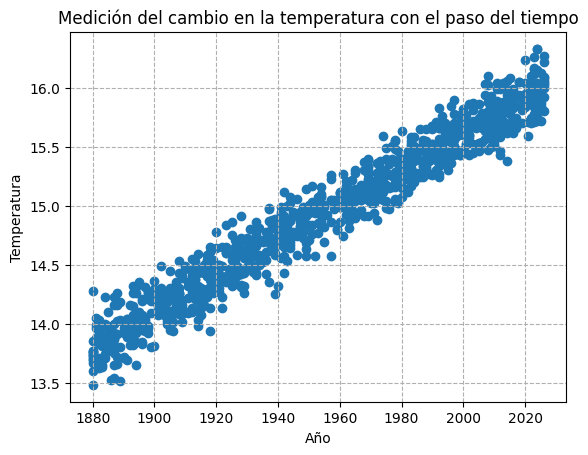

In [7]:
# Visualización de la relación entre las variables
plt.scatter(df['anio'], df['temperatura'])
plt.title('Medición del cambio en la temperatura con el paso del tiempo')
plt.xlabel('Año')
plt.ylabel('Temperatura')
plt.grid(True, linestyle='--')
plt.show()

In [9]:
# Selección de variables

# X es la variable independiente
X = df[['anio']]
#  y es la variable objetivo
y = df['temperatura']

In [10]:
# División de datos (Entrenamiento y prueba)

# Importamos la librería para la separación
from sklearn.model_selection import train_test_split

In [11]:
# Reservamos el 30% de los datos para probar el modelo al final

### -----> CAMBIAR en random_state=0 el 0 por su número de MATRÍCULA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1068493)

# **Fase 4: Entrenamiento del Modelo (Scikit-Learn)**

In [12]:
# Importamos la librería para la regresión lineal
from sklearn.linear_model import LinearRegression

In [13]:
# Creación del Modelo
LR = LinearRegression()

In [14]:
# Entrenamiento del Modelo
LR.fit(X_train, y_train)

LinearRegression()

In [15]:
# Verificamos el ajuste a los datos de entrenamiento
LR.score(X_train, y_train)

0.9470666759809346

Cálculo de los coeficientes de la ecuación de regresión lineal

In [16]:
# Pendiente de la recta
b1 = LR.coef_
print("Pendiente de la recta \n m =", b1)

Pendiente de la recta 
 m = [0.01485631]


In [17]:
# Intersección con el eje y
b0 = LR.intercept_
print("Intersección con el eje y \n b =", b0)

Intersección con el eje y 
 b = -14.105821548833397


# **Fase 5: Validación y Predicción**

In [18]:
# Importamos la librería para la métrica r^2
from sklearn.metrics import r2_score

In [19]:
# Cálculo de r^2
# Una puntuación de 1 indica un ajuste perfecto
# Una puntuación de 0 indica que el modelo no es apto para predecir la variable objetivo

r2 = LR.score(X_test, y_test)
print("R^2 score =", r2)

R^2 score = 0.9539166550699858


In [ ]:
# Visualización del Modelo Resultante
pred = LR.predict(X_test)
plt.scatter(X, y, label='Datos reales')
plt.plot(X_test, pred, color='blue', linewidth=2, label='Línea de Regresión')
plt.title('Modelo de Predicción del clima')
plt.xlabel('Año')
plt.ylabel('Temperatura(°C)')
plt.legend()
plt.show()

# **Fase 6: Hacia el Despliegue (Streamlit)**

El objetivo de Streamlit es permitir que cualquier persona (un biólogo marino, un político o un ciudadano) use nuestro modelo de IA sin necesidad de saber programar.

In [21]:
%%writefile Corales.py
# Importar librerías necearias
import numpy as np
import streamlit as st
import pandas as pd

# Insertamos título
st.write(''' # ODS 13: Acción por el clima ''')
# Insertamos texto con formato
st.markdown("""
Esta aplicación utiliza **Machine Learning** para predecir el cambio climatico con el paso de los años, alineado con el **ODS 3: Acción por el clima**.
""")
# Insertamos una imagen
st.image("clima.jpg", caption="El impacto de nuestras acciones reflejado en el cambio climatico con el paso del tiempo")

#st.header('Datos personales')

# Definimos cómo ingresará los datos el usuario
# Usaremos un deslizador
st.header("Año")
# Definimos los parámetros de nuestro deslizador:
  # Límite inferior: 24°C. Es el límite inferior donde los arrecifes tropicales suelen estar cómodos
  # Límite superior: 35°C. La mayoría de los corales mueren o se blanquean totalmente mucho antes de llegar a esa temperatura
  # Valor inicial: 28°C. En muchos arrecifes, a partir de los 28.5°C o 29°C comienza el estrés térmico severo
temp_input = st.sidnumber_input("Año", 1880.0, 2026.0, 2020.0)

# Cargamos el archivo con los datos (.csv)
df =  pd.read_csv('Temperatura.csv', encoding='latin-1')
# Seleccionamos las variables
X = df[['anio']]
y = df['temperatura']

# Creamos y entrenamos el modelo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)
LR = LinearRegression()
LR.fit(X_train,y_train)

# Hacemos la predicción con el modelo y la temperatura seleccionada por el usuario
b1 = LR.coef_
b0 = LR.intercept_
prediccion = b0 + b1[0]*temp_input

# Presentamos loa resultados
st.subheader('Temperatura')
st.write(f'La temperatura de ese año es {prediccion:.2f}%')


Overwriting Corales.py
